# Notebook 1 — RMR Dataset Generation
## Targets: RMR · Rock Class · Bolt Density · Bolt Length · Shotcrete Thickness
## Inputs: 6 RMR89 params + Excavation Span · Depth · Excavation Method

References used throughout:
- Bieniawski (1989) — RMR89 classification, Table 2 ratings, Table 5 support
- Lowson & Bieniawski (2013) — bolt length vs span charts
- Rehman et al. (2018) — shotcrete span scaling
- Hoek & Marinos (2000) — squeezing criterion
- Barton et al. (1974) — TBM vs D&B correction
- Noise: Hack (2002), Palmstrom (2005), Cai et al. (2004), Jakubec & Laubscher (2000)


In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
CLASS_ORDER  = ['I', 'II', 'III', 'IV', 'V']
CLASS_COLORS = {'I':'#2ecc71','II':'#3498db','III':'#f39c12','IV':'#e67e22','V':'#e74c3c'}


---
## 1. RMR89 Rating Functions
Direct lookup from Bieniawski (1989) Table 2. Nothing fancy here — just implementing the rating scales.


In [56]:
def ucs_rating(u):
    # Table 2, Parameter 1 — max 15 pts
    if   u > 250: return 15
    elif u > 100: return 12
    elif u > 50:  return 7
    elif u > 25:  return 4
    elif u > 5:   return 2
    else:         return 1

def rqd_rating(r):
    # Table 2, Parameter 2 — max 20 pts
    if   r >= 90: return 20
    elif r >= 75: return 17
    elif r >= 50: return 13
    elif r >= 25: return 8
    else: return 3

def js_rating(s):
    # Table 2, Parameter 3 — max 20 pts
    if   s > 2: return 20
    elif s > 0.6: return 15
    elif s > 0.2:return 10
    elif s > 0.06: return 8
    else: return 5
# discrete maps — Table 2 Parameters 4 and 5
JC_MAP = {1: 30, 2: 25, 3: 20, 4: 10, 5: 0}
GW_MAP = {1: 15, 2: 10, 3: 7,  4: 4,  5: 0}
ORIENT_VALUES = [0, -2, -5, -10, -12]
def compute_rmr(ucs, rqd, js, jc, gw, orient):
    # RMR89 = R1+R2+R3+R4+R5+B  (Bieniawski 1989, Eq.1)
    return (ucs_rating(ucs) + rqd_rating(rqd) + js_rating(js)
            + JC_MAP[jc] + GW_MAP[gw] + orient)
def get_class(rmr):
    # Table 4 thresholds
    if   rmr >= 81: return 'I'
    elif rmr >= 61: return 'II'
    elif rmr >= 41: return 'III'
    elif rmr >= 21: return 'IV'
    else: return 'V'


---
## 2. Support Design Functions

Three targets computed per sample:
- **Bolt Density** — from Bieniawski Table 5 spacing → density = 1/s²
- **Bolt Length** — max of (Table 5 base, span fraction from Lowson & Bieniawski 2013), then depth and method modifiers
- **Shotcrete** — Table 5 base × span scaling (Rehman 2018) × depth factor × method factor


In [57]:
# BOLT DENSITY (from Bieniawski 1989 Table 5)
# Bolt spacing → areal density = 1/spacing² (square pattern assumed)
# Class I:  no support→ 0.00 bolts/m²
# Class II: 2.5m spacing → 1/2.5² = 0.16 bolts/m²
# Class III: 1.5m spacing → 1/1.5² = 0.44 bolts/m²
# Class IV: 1.0m spacing → 1/1.0² = 1.00 bolts/m²
# Class V:  0.75m spacing → 1/0.75² = 1.78 bolts/m²
BOLT_DENSITY_MAP = {'I': 0.00, 'II': 0.16, 'III': 0.44, 'IV': 1.00, 'V': 1.78}

#DEPTH/STRESS MODIFIER
def depth_stress_factor(rmr, depth_m, ucs_mpa):  
    sigma_v  = 0.027 * depth_m                                # MPa
    sigma_cm = 0.5 * ucs_mpa * np.exp((rmr - 100) / 24.0)   # Hoek et al. (2002)
    sigma_cm = max(sigma_cm, 0.5)                             # physical floor
    ratio = sigma_v / sigma_cm
    df = min(1.5, 1.0 + 0.3 * max(0.0, ratio - 0.2))
    return df
# BOLT LENGTH
def base_bolt_length(rmr):
    if   rmr >= 81: return 2.0
    elif rmr >= 61: return 3.0
    elif rmr >= 41: return 4.0
    elif rmr >= 21: return 4.5
    else: return 5.5
def span_fraction(rmr):
    if   rmr >= 61: return 0.30   # good to very good rock
    elif rmr >= 41: return 0.40   # fair rock
    elif rmr >= 21: return 0.50   # poor rock
    else: return 0.60   # very poor rock
def compute_bolt_length(rmr, span, depth, ucs, excavation_method):   
    lb_base = base_bolt_length(rmr)
    lb_span = span_fraction(rmr) * span
    lb = max(lb_base, lb_span)
    # Excavation method modifier (TBM = less disturbed tunnel wall)
    if excavation_method == 0:  # TBM
        lb *= 0.90
    # D&B = 1: no change (Bieniawski table is D&B reference)
    
    # Depth/stress modifier
    df= depth_stress_factor(rmr, depth, ucs)
    lb *= (1.0 + 0.5 * (df - 1.0))  # half the stress amplification
    return float(np.clip(lb, 2.0, 7.0))

# SHOTCRETE THICKNESS
def base_shotcrete_mm(rmr):
    if   rmr >= 81: return 0.0
    elif rmr >= 61: return 25.0
    elif rmr >= 41: return 75.0
    elif rmr >= 21: return 125.0
    else: return 175.0
def compute_shotcrete_mm(rmr, span, depth, ucs, excavation_method):
    t_base = base_shotcrete_mm(rmr)
    # Class I: no shotcrete regardless of span/depth/method
    if t_base == 0.0:
        return 0.0
    # Span scaling (Rehman et al. 2018; Lowson & Bieniawski 2013)
    t_sc = t_base * (span / 10.0)
    # TBM reduction
    if excavation_method == 0:  # TBM
        t_sc *= 0.80
    # Depth/stress modifier
    df   = depth_stress_factor(rmr, depth, ucs)
    t_sc *= df
    return float(np.clip(t_sc, 0.0, 250.0))
print('support functions defined.')
print()
print('=== QUICK SELF-CHECK ===')
# Verify against Bieniawski Table 5 reference point (RMR~50, 10m span, D&B, H=200m)
for rmr, cls, expected_lb, expected_t in [
    (90, 'I',   '2-3m',    '0mm'),
    (70, 'II',  '3m',      '25mm'),
    (50, 'III', '4m',      '75mm'),
    (30, 'IV',  '4-5m',    '125mm'),
    (10, 'V',   '5-6m',    '175mm'),
]:
    lb = compute_bolt_length(rmr, 10, 200, 50, 1)
    t  = compute_shotcrete_mm(rmr, 10, 200, 50, 1)
    print(f'  RMR={rmr:3d} (Class {cls}): Lb={lb:.1f}m [{expected_lb}], t_sc={t:.0f}mm [{expected_t}]')

support functions defined.

=== QUICK SELF-CHECK ===
  RMR= 90 (Class I): Lb=3.1m [2-3m], t_sc=0mm m]
  RMR= 70 (Class II): Lb=3.2m [3m], t_sc=29mm m]
  RMR= 50 (Class III): Lb=4.9m [4m], t_sc=110mm m]
  RMR= 30 (Class IV): Lb=6.2m [4-5m], t_sc=188mm m]
  RMR= 10 (Class V): Lb=7.0m [5-6m], t_sc=250mm m]


---
## 3. Measurement Noise

Noise magnitudes calibrated from published sources:
- UCS, Joint Spacing: multiplicative σ=12% (Hack 2002)
- RQD: additive σ=5% (Palmstrom 2005)
- JC, GW, Orientation: discrete ±1 shift with p=20% (Cai et al. 2004; Jakubec & Laubscher 2000)

In [52]:
def add_measurement_noise(ucs, rqd, js, jc, gw, orient,
                          ucs_noise_std=0.12,
                          rqd_noise_std=5.0,
                          js_noise_std=0.12,
                          discrete_flip_prob=0.20,
                          rng=None):
    if rng is None:
        rng = np.random.default_rng()
    # continuous params — multiplicative noise
    ucs_n = max(1.0, ucs * (1 + rng.normal(0, ucs_noise_std)))
    rqd_n = float(np.clip(rqd + rng.normal(0, rqd_noise_std), 0, 100))
    js_n  = max(0.01, js * (1 + rng.normal(0, js_noise_std)))
    # discrete params — random ±1 shift with probability p
    jc_n = int(np.clip(jc + rng.choice([-1,1]), 1, 5)) if rng.random() < discrete_flip_prob else jc
    gw_n = int(np.clip(gw + rng.choice([-1,1]), 1, 5)) if rng.random() < discrete_flip_prob else gw
    orient_vals = [0, -2, -5, -10, -12]
    if rng.random() < discrete_flip_prob:
        idx = orient_vals.index(orient)
        new_idx = int(np.clip(idx + rng.choice([-1,1]), 0, len(orient_vals)-1))
        orient_n = orient_vals[new_idx]
    else:
        orient_n = orient
    return ucs_n, rqd_n, js_n, jc_n, gw_n, orient_n

print('noise function ready')


noise function ready


---
## 4. Feature Ranges

Span (4-16m) and Depth (50-900m) sampled uniformly and independently of rock class.
Bieniawski's table is valid for σv < 25 MPa → depth upper limit ~926m.
Excavation method is binary: 0=TBM, 1=D&B.


In [58]:
# Parameter ranges per RMR class for the 6 RMR89 parameters
CLASS_PARAMS = {
    'I':  {'ucs':(100,250), 'rqd':(80,100), 'js':(0.8,2.0),  'jc':[1,2],    'gw':[1,2],    'orient':[0,-2]},
    'II': {'ucs':(50,150),  'rqd':(60,90),  'js':(0.4,1.2),  'jc':[1,2,3],  'gw':[1,2,3],  'orient':[0,-2,-5]},
    'III':{'ucs':(25,100),  'rqd':(40,75),  'js':(0.15,0.7), 'jc':[2,3,4],  'gw':[2,3,4],  'orient':[-2,-5,-10]},
    'IV': {'ucs':(5,60),    'rqd':(15,50),  'js':(0.05,0.25),'jc':[3,4,5],  'gw':[3,4,5],  'orient':[-5,-10,-12]},
    'V':  {'ucs':(1,25),    'rqd':(0,25),   'js':(0.01,0.1), 'jc':[4,5],    'gw':[4,5],    'orient':[-10,-12]},
}

# New feature ranges
SPAN_RANGE = (4.0, 16.0) # metres — Lowson & Bieniawski (2013) design chart range
DEPTH_RANGE = (50.0, 900.0) # metres — Bieniawski (1989) upper limit σv<25MPa
METHODS = [0, 1] # 0=TBM, 1=Drill&Blast

print('Feature ranges defined.')
print(f'Span range  : {SPAN_RANGE[0]}–{SPAN_RANGE[1]} m')
print(f'Depth range : {DEPTH_RANGE[0]}–{DEPTH_RANGE[1]} m')
print(f'Methods     : 0=TBM, 1=D&B')

Feature ranges defined.
Span range  : 4.0–16.0 m
Depth range : 50.0–900.0 m
Methods     : 0=TBM, 1=D&B


---
## 5. Dataset Generation

200 samples per class, rejection-sampled to ensure RMR falls within correct class bounds.
Targets computed from clean parameters; noise applied only to input features.


In [59]:
rng = np.random.default_rng(SEED)
SAMPLES_PER_CLASS = 200
MAX_ATTEMPTS = 5000  # rejection sampling limit per sample

rows = []

for cls in CLASS_ORDER:
    p   = CLASS_PARAMS[cls]
    n_gen = 0
    while n_gen < SAMPLES_PER_CLASS:
        # Draw RMR89 parameters
        for attempt in range(MAX_ATTEMPTS):
            ucs = rng.uniform(*p['ucs'])
            rqd = rng.uniform(*p['rqd'])
            js= rng.uniform(*p['js'])
            jc= int(rng.choice(p['jc']))
            gw = int(rng.choice(p['gw']))
            orient = int(rng.choice(p['orient']))
            rmr_clean = compute_rmr(ucs, rqd, js, jc, gw, orient)
            # Rejection: accept only if RMR falls in correct class
            if get_class(rmr_clean) == cls:
                break
        else:
            # Fallback: accept best attempt (very rare)
            pass
        # Draw new features
        span   = rng.uniform(*SPAN_RANGE)
        depth  = rng.uniform(*DEPTH_RANGE)
        method = int(rng.choice(METHODS))  # 0=TBM, 1=D&B
        # Compute targets from CLEAN parameters
        true_class    = get_class(rmr_clean)
        bolt_density  = BOLT_DENSITY_MAP[true_class]
        bolt_length   = compute_bolt_length(rmr_clean, span, depth, ucs, method)
        shotcrete_mm  = compute_shotcrete_mm(rmr_clean, span, depth, ucs, method)
        #Apply measurement noise to RMR89 inputs
        ucs_m, rqd_m, js_m, jc_m, gw_m, orient_m = add_measurement_noise(
            ucs, rqd, js, jc, gw, orient, rng=rng
        )
        # Compute measured RMR and class 
        rmr_measured   = compute_rmr(ucs_m, rqd_m, js_m, jc_m, gw_m, orient_m)
        measured_class = get_class(rmr_measured)
        rows.append({
            # 9 Input features
            'UCS_MPa': round(ucs_m, 2),          # measured (noisy)
            'RQD_percent':round(rqd_m, 2),
            'Joint_Spacing_m': round(js_m,  4),
            'Joint_Condition':jc_m,
            'Groundwater':gw_m,
            'Joint_Orientation_adj': orient_m,
            'Excavation_Span_m': round(span,  2),          # no noise on structural params
            'Depth_m': round(depth, 1),
            'Excavation_Method': method,                   # 0=TBM, 1=D&B
            # 4 Output targets
            'RMR': rmr_clean,
            'True_Rock_Class': true_class,
            'Measured_Rock_Class': measured_class,
            'Bolt_Density_per_m2': bolt_density,
            'Bolt_Length_m':round(bolt_length, 2),
            'Shotcrete_mm':round(shotcrete_mm, 1),

            'UCS_clean':round(ucs,   2),
            'RQD_clean': round(rqd,   2),
            'JS_clean': round(js,    4),
            'Depth_factor': round(depth_stress_factor(rmr_clean, depth, ucs), 3),
        })
        n_gen += 1

    print(f'  Class {cls}: {n_gen} samples generated.')
df = pd.DataFrame(rows)
print(f'\nDataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
# quick check — Class V took the most rejection attempts due to narrow RMR range (<21)
# Class I was surprisingly fast, broad UCS range helps


  Class I: 200 samples generated.
  Class II: 200 samples generated.
  Class III: 200 samples generated.
  Class IV: 200 samples generated.
  Class V: 200 samples generated.

Dataset shape: (1000, 19)
Columns: ['UCS_MPa', 'RQD_percent', 'Joint_Spacing_m', 'Joint_Condition', 'Groundwater', 'Joint_Orientation_adj', 'Excavation_Span_m', 'Depth_m', 'Excavation_Method', 'RMR', 'True_Rock_Class', 'Measured_Rock_Class', 'Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm', 'UCS_clean', 'RQD_clean', 'JS_clean', 'Depth_factor']


---
## 6. Quick Quality Checks


In [31]:
print('=== DATASET SUMMARY ===')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print()
print('True Rock Class distribution:')
print(df['True_Rock_Class'].value_counts().sort_index())
print()
print('Measured Rock Class distribution (after noise):')
print(df['Measured_Rock_Class'].value_counts().sort_index())
print()
shifted = (df['True_Rock_Class'] != df['Measured_Rock_Class']).sum()
print(f'Samples shifted across class boundary by noise: {shifted} ({shifted/len(df)*100:.1f}%)')
print()
print('--- Excavation Method distribution ---')
print(df['Excavation_Method'].value_counts().rename({0:'TBM', 1:'D&B'}))
print()
print('--- Target variable ranges ---')
for col in ['RMR','Bolt_Density_per_m2','Bolt_Length_m','Shotcrete_mm']:
    print(f'  {col:<25}: min={df[col].min():.2f}  max={df[col].max():.2f}  mean={df[col].mean():.2f}')

=== DATASET SUMMARY ===
Shape: (1000, 19)
Missing values: 0
Duplicate rows : 0

True Rock Class distribution:
True_Rock_Class
I      200
II     200
III    200
IV     200
V      200
Name: count, dtype: int64

Measured Rock Class distribution (after noise):
Measured_Rock_Class
I      184
II     222
III    183
IV     205
V      206
Name: count, dtype: int64

Samples shifted across class boundary by noise: 105 (10.5%)

--- Excavation Method distribution ---
Excavation_Method
TBM    515
D&B    485
Name: count, dtype: int64

--- Target variable ranges ---
  RMR                      : min=-3.00  max=92.00  mean=49.00
  Bolt_Density_per_m2      : min=0.00  max=1.78  mean=0.68
  Bolt_Length_m            : min=2.00  max=7.00  mean=4.95
  Shotcrete_mm             : min=0.00  max=250.00  mean=98.37


In [60]:
# Descriptive statistics per class
FEATURE_COLS = ['UCS_MPa','RQD_percent','Joint_Spacing_m','Joint_Condition','Groundwater','Joint_Orientation_adj','Excavation_Span_m','Depth_m','Excavation_Method']
TARGET_COLS  = ['RMR','Bolt_Density_per_m2','Bolt_Length_m','Shotcrete_mm']
df.groupby('True_Rock_Class')[TARGET_COLS].agg(['mean','std']).round(2).reindex(CLASS_ORDER)

RMR       Bolt_Density_per_m2      Bolt_Length_m        \
                  mean   std                mean  std          mean   std   
True_Rock_Class                                                             
I                86.02  3.02                0.00  0.0          3.04  0.92   
II               71.66  5.49                0.16  0.0          3.58  0.69   
III              50.50  5.81                0.44  0.0          5.27  0.87   
IV               29.38  5.36                1.00  0.0          6.08  0.77   
V                 7.46  5.80                1.78  0.0          6.77  0.33   

                Shotcrete_mm         
                        mean    std  
True_Rock_Class                      
I                       0.00   0.00  
II                     26.68  10.47  
III                    96.19  34.13  
IV                    162.08  55.06  
V                     206.91  49.63

---
## 7. Distribution Plots


NameError: name 'fig_test' is not defined

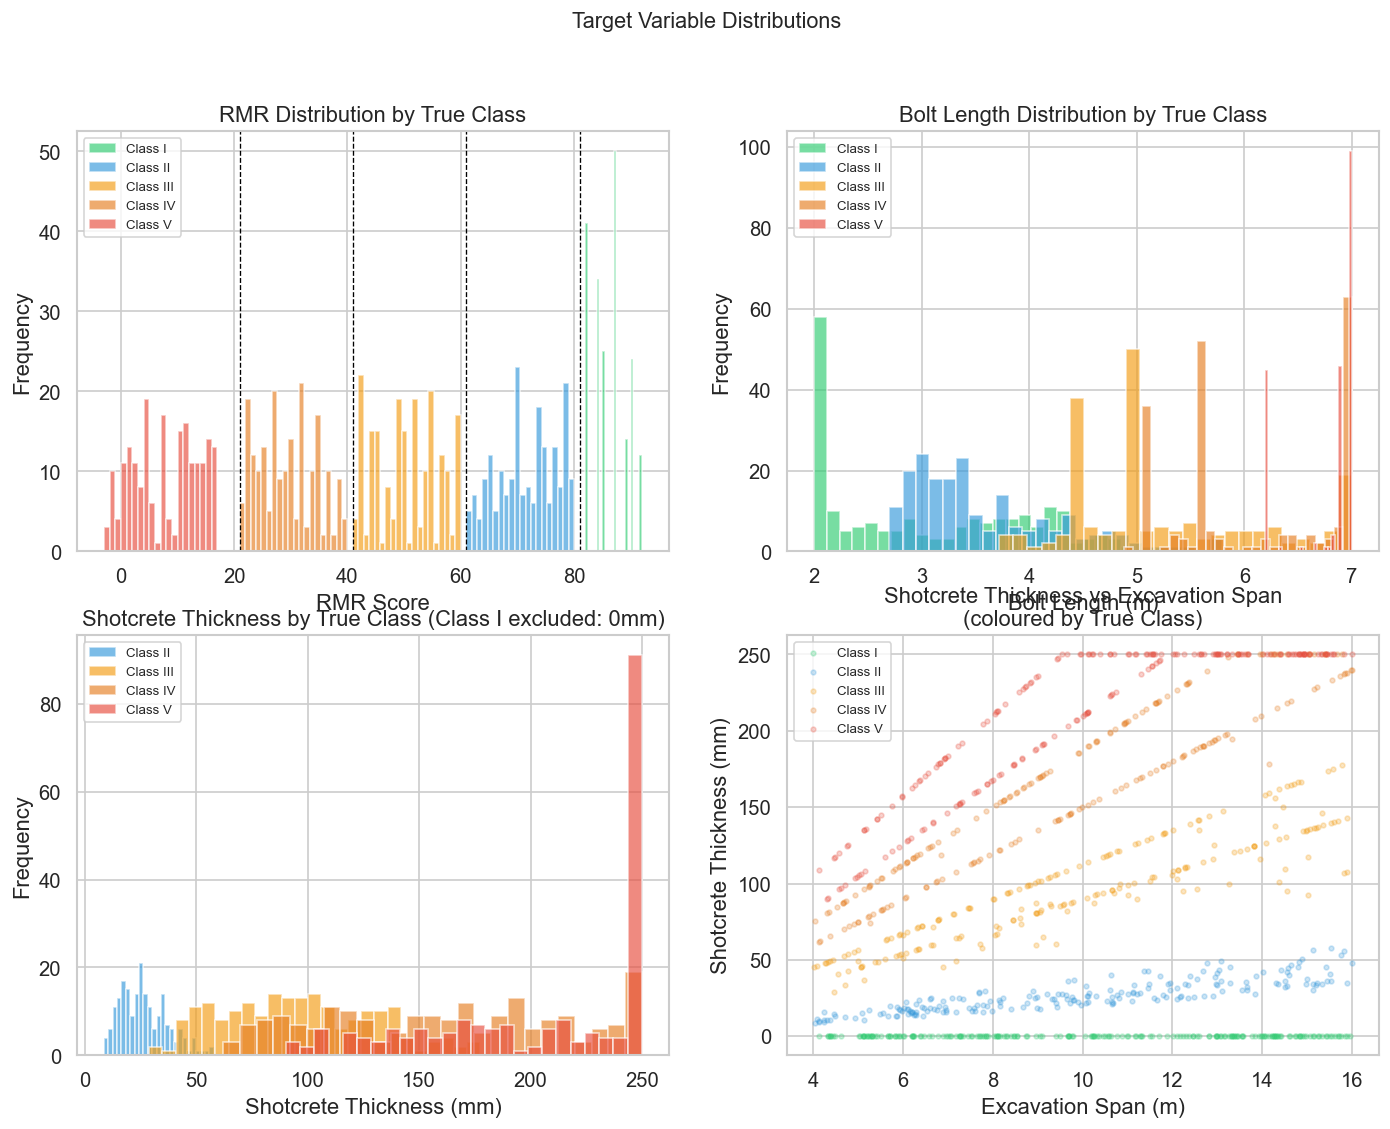

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMR distribution
ax = axes[0,0]
for cls in CLASS_ORDER:
    subset = df[df['True_Rock_Class'] == cls]['RMR']
    ax.hist(subset, bins=20, alpha=0.65, color=CLASS_COLORS[cls], label=f'Class {cls}')
for boundary in [21, 41, 61, 81]:
    ax.axvline(boundary, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('RMR Score'); ax.set_ylabel('Frequency')
ax.set_title('RMR Distribution by True Class')
ax.legend(fontsize=8)
#Bolt length distribution
ax = axes[0,1]
for cls in CLASS_ORDER:
    subset = df[df['True_Rock_Class'] == cls]['Bolt_Length_m']
    ax.hist(subset, bins=25, alpha=0.65, color=CLASS_COLORS[cls], label=f'Class {cls}')
ax.set_xlabel('Bolt Length (m)'); ax.set_ylabel('Frequency')
ax.set_title('Bolt Length Distribution by True Class')
ax.legend(fontsize=8)
#Shotcrete thickness distribution
ax = axes[1,0]
for cls in ['II','III','IV','V']:  # Class I = 0mm so skip to keep scale readable
    subset = df[df['True_Rock_Class'] == cls]['Shotcrete_mm']
    ax.hist(subset, bins=25, alpha=0.65, color=CLASS_COLORS[cls], label=f'Class {cls}')
ax.set_xlabel('Shotcrete Thickness (mm)'); ax.set_ylabel('Frequency')
ax.set_title('Shotcrete Thickness by True Class (Class I excluded: 0mm)')
ax.legend(fontsize=8)
#Shotcrete vs Span scatter (key relationship to illustrate
ax = axes[1,1]
for cls in CLASS_ORDER:
    subset = df[df['True_Rock_Class'] == cls]
    ax.scatter(subset['Excavation_Span_m'], subset['Shotcrete_mm'],
               alpha=0.25, s=8, color=CLASS_COLORS[cls], label=f'Class {cls}')
ax.set_xlabel('Excavation Span (m)'); ax.set_ylabel('Shotcrete Thickness (mm)')
ax.set_title('Shotcrete Thickness vs Excavation Span\n(coloured by True Class)')
ax.legend(fontsize=8)

plt.suptitle('Target Variable Distributions', fontsize=13)
fig_test.tight_layout(pad=1.5)
plt.savefig('fig_targets.png')
plt.show()

NameError: name 'fig_test' is not defined

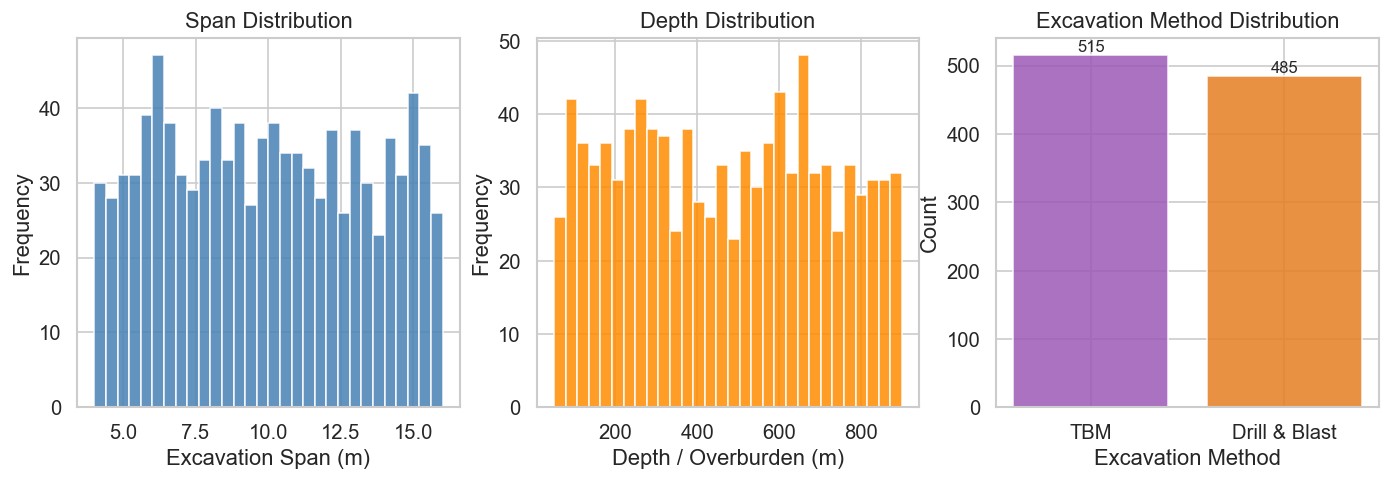

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Span
axes[0].hist(df['Excavation_Span_m'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Excavation Span (m)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Span Distribution')
# Depth
axes[1].hist(df['Depth_m'], bins=30, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Depth / Overburden (m)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Depth Distribution')
# Method
method_counts = df['Excavation_Method'].value_counts().rename({0:'TBM', 1:'Drill & Blast'})
axes[2].bar(method_counts.index, method_counts.values,
            color=['#9b59b6','#e67e22'], edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Excavation Method'); axes[2].set_ylabel('Count')
axes[2].set_title('Excavation Method Distribution')
for i, v in enumerate(method_counts.values):
    axes[2].text(i, v+5, str(v), ha='center', fontsize=10)

fig_test.suptitle('Span, Depth & Excavation Method Distributions', fontsize=13)
fig_test.tight_layout(pad=1.5)
fig_test.savefig('fig_features.png')
fig_test.show()

NameError: name 'fig_test' is not defined

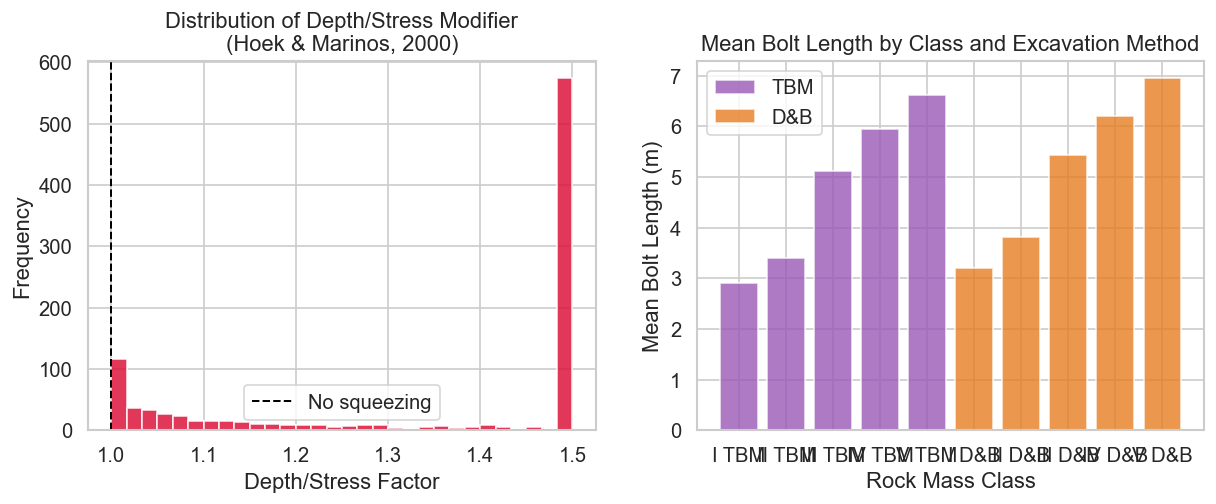

In [47]:
#Depth factor distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Depth_factor'], bins=30, color='crimson', edgecolor='white', alpha=0.85)
axes[0].axvline(1.0, color='black', linewidth=1.2, linestyle='--', label='No squeezing')
axes[0].set_xlabel('Depth/Stress Factor'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Depth/Stress Modifier\n(Hoek & Marinos, 2000)')
axes[0].legend()

#Bolt length by class and method
for method, label, color in [(0,'TBM','#9b59b6'),(1,'D&B','#e67e22')]:
    means = df[df['Excavation_Method']==method].groupby('True_Rock_Class')['Bolt_Length_m'].mean()
    axes[1].bar([c+(' TBM' if method==0 else ' D&B') for c in CLASS_ORDER],
                [means.get(c,0) for c in CLASS_ORDER],
                color=color, alpha=0.8, edgecolor='white', label=label)
axes[1].set_xlabel('Rock Mass Class'); axes[1].set_ylabel('Mean Bolt Length (m)')
axes[1].set_title('Mean Bolt Length by Class and Excavation Method')
axes[1].legend()
fig_test.xticks(rotation=30, ha='right')

fig_test.suptitle('Depth Stress Effect and Method Comparison', fontsize=13)
fug_test.tight_layout()
fig_test.savefig('fig_depth_method.png')
fig_test.show()

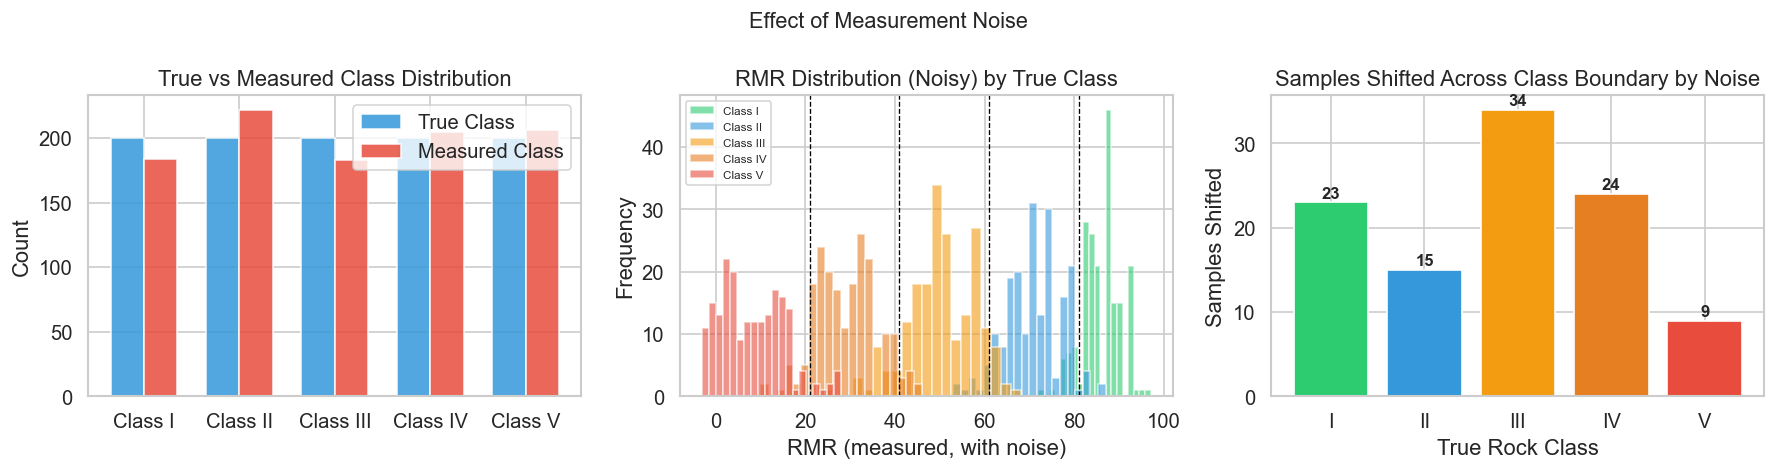

In [36]:
#Noise effect on class boundary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# True vs Measured class counts
true_counts     = df['True_Rock_Class'].value_counts().reindex(CLASS_ORDER)
measured_counts = df['Measured_Rock_Class'].value_counts().reindex(CLASS_ORDER)
x = np.arange(len(CLASS_ORDER))
w = 0.35
axes[0].bar(x - w/2, true_counts.values,     width=w, label='True Class',     color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, measured_counts.values, width=w, label='Measured Class', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
axes[0].set_ylabel('Count'); axes[0].set_title('True vs Measured Class Distribution')
axes[0].legend()
# RMR noisy distribution
rmr_noisy = df.apply(
    lambda r: compute_rmr(r.UCS_MPa, r.RQD_percent, r.Joint_Spacing_m,
                          r.Joint_Condition, r.Groundwater, r.Joint_Orientation_adj), axis=1
)
for cls in CLASS_ORDER:
    mask = df['True_Rock_Class'] == cls
    axes[1].hist(rmr_noisy[mask], bins=20, alpha=0.6, color=CLASS_COLORS[cls], label=f'Class {cls}')
for b in [21,41,61,81]:
    axes[1].axvline(b, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('RMR (measured, with noise)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('RMR Distribution (Noisy) by True Class')
axes[1].legend(fontsize=7)
# Samples shifted per class
shifted_per_class = (
    df[df['True_Rock_Class'] != df['Measured_Rock_Class']]
    .groupby('True_Rock_Class').size().reindex(CLASS_ORDER, fill_value=0)
)
colors_shift = [CLASS_COLORS[c] for c in CLASS_ORDER]
bars = axes[2].bar(CLASS_ORDER, shifted_per_class.values, color=colors_shift, edgecolor='white')
for bar, v in zip(bars, shifted_per_class.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5, str(v),
    ha='center', fontsize=10, fontweight='bold')
axes[2].set_xlabel('True Rock Class'); axes[2].set_ylabel('Samples Shifted')
axes[2].set_title('Samples Shifted Across Class Boundary by Noise')
plt.suptitle('Effect of Measurement Noise', fontsize=13)
plt.tight_layout()
plt.savefig('fig_noise_effect.png')
plt.show()

In [37]:
# interesting — Class IV shows the most boundary crossings
# makes sense since RMR 21-40 is a narrow band and noise easily pushes samples into III or V
# Class I barely shifts — high RMR values have a lot of headroom before crossing 81
shifted = (df['True_Rock_Class'] != df['Measured_Rock_Class']).sum()
print(f'Total boundary crossings: {shifted} / {len(df)} = {shifted/len(df)*100:.1f}%')
print(df[df['True_Rock_Class'] != df['Measured_Rock_Class']].groupby('True_Rock_Class').size())

Total boundary crossings: 105 / 1000 = 10.5%
True_Rock_Class
I      23
II     15
III    34
IV     24
V       9
dtype: int64


---
## 8. Correlation Analysis

Checking which input features correlate most with each target.


NameError: name 'fig_test' is not defined

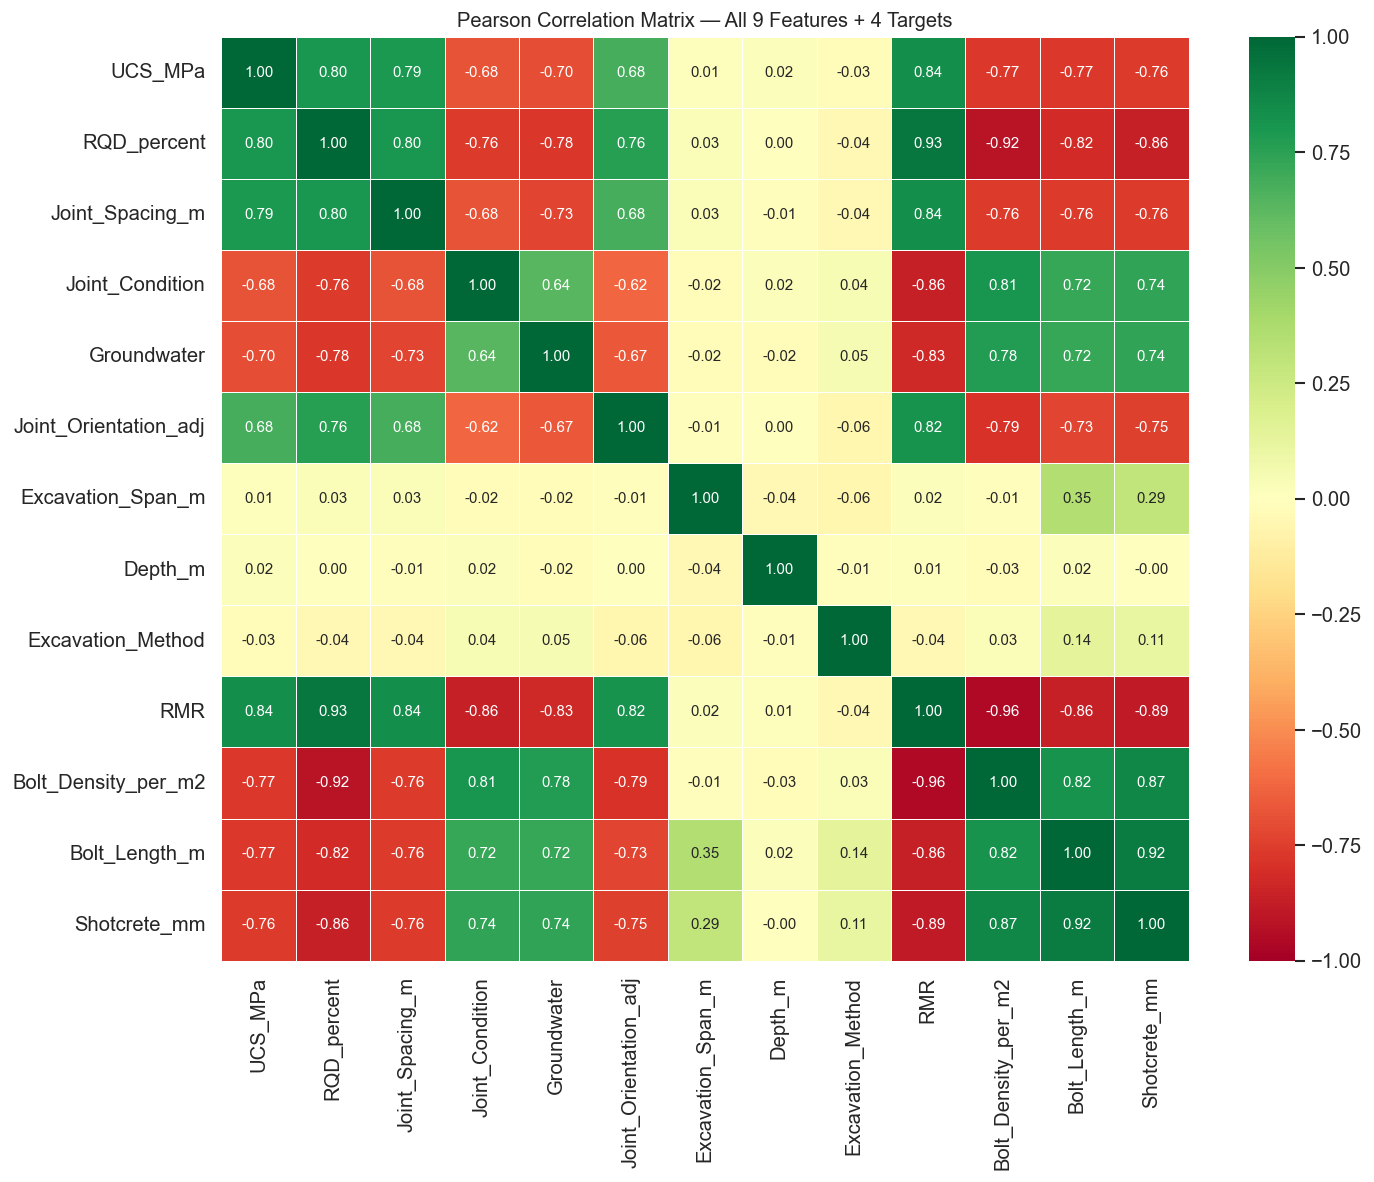

In [61]:
numeric_cols = FEATURE_COLS + TARGET_COLS
corr = df[numeric_cols].corr().round(2)
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr, dtype=bool)
# Show full matrix (no mask) for complete feature-target relationships
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix — All 9 Features + 4 Targets', fontsize=12)
fig_test.tight_layout(pad=1.5)
plt.savefig('fig_correlation.png')
plt.show()
print('=== Feature-Target Correlations (with new targets) ===')
for target in TARGET_COLS:
    top = corr[target].drop(TARGET_COLS).abs().sort_values(ascending=False)
    print(f'\n{target}:')
    for feat, val in top.items():
        print(f'  {feat:<28}: {corr[target][feat]:+.3f}')

---
## 9. Save


In [62]:
# Select final column order for the CSV
OUTPUT_COLS = [
    'UCS_MPa', 'RQD_percent', 'Joint_Spacing_m','Joint_Condition', 'Groundwater', 'Joint_Orientation_adj','Excavation_Span_m', 'Depth_m', 'Excavation_Method','RMR', 'True_Rock_Class', 'Measured_Rock_Class','Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm','UCS_clean', 'RQD_clean', 'JS_clean', 'Depth_factor',
]

df_out = df[OUTPUT_COLS]
df_out.to_csv('rmr_dataset.csv', index=False)